# 第18课 · 信息丢了还能还原吗？——可逆性与秩（rank）、零空间（null space）与奇异矩阵诊断

**目标**：判断一个方阵是否可逆的三条判据，以及「严格对角占优」这一快速充分条件。

**诊断流程图（先贴墙上）**：
```
rank(A) < n  ──→  奇异 / 不可逆（信息丢了）
     │
rank = n ──→ det(A) ≠ 0 ──→ 可逆
     │              └── det=0 ──→ 不可逆（与「有零特征值」同义）
零空间有非零向量 ──→ 同样 ⇒ 不可逆
```
术语与 L15/L16 对齐：**奇异 = 不可逆 = det=0 = 不满秩**（方阵情形）。

**为什么对 Aurora 重要**：Jacobi/Gauss-Seidel 迭代求解器以对角占优为收敛前提；`is_sdd` 检查是求解器入口的第一道关卡。

← **上一课**　[L17 · 特征分解 A=PDP⁻¹](L17_eigen_diagonalization.ipynb)

> 上节课学习了 **特征分解 A=PDP⁻¹**：换坐标系让矩阵乘法变成标量乘法。  
> 本课将探讨 **可逆性与秩**。

## 本课剧情：信息有没有丢失？

想象你把一段语音压缩成 MP3。有损压缩 = 信息丢失 = 不可逆。  
想象你对信号做 FFT。FFT 是可逆的——有 ifft 可以完美还原。

矩阵也有同样的区分：
- **可逆矩阵**：把每个输入映射到唯一输出；知道输出，就能还原输入。信息没有丢失。
- **奇异矩阵（singular）**：把多个不同输入压缩到同一输出，无法区分；信息丢失了。

判断可逆性有三条等价充要条件：

| 判据 | 工具 | 计算复杂度 |
|---|---|---|
| `det(A) ≠ 0` | `np.linalg.det` | O(n³) |
| 所有特征值 ≠ 0 | `np.linalg.eigvals` | O(n³) |
| 严格对角占优（SDD）| 逐行检查 | O(n²)——快！ |

本课实现 `is_sdd(A)`，这是迭代求解器（Jacobi/Gauss-Seidel）的入口卫士：通过 SDD 检查的矩阵，才有足够强的收敛保证。

## 1. 三条等价判据

**判据 1：det(A) ≠ 0**（充要）  
行列式等于零 ↔ 矩阵把空间"压扁"了一个维度 ↔ 信息丢失 ↔ 不可逆。

**判据 2：所有特征值 ≠ 0**（充要）  
特征值 = 各方向的缩放因子。有一个方向缩放为 0 → 那个方向的信息丢失 → 不可逆。

**判据 3：严格对角占优（SDD）**（充分条件，非充要）  
对每行 i：`|A[i,i]| > Σ_{j≠i} |A[i,j]|`  
也就是：主对角元素的绝对值 > 该行其他所有元素绝对值之和。  
SDD → 可逆（但可逆矩阵不一定 SDD）。

**手算例子**：A = [[3, 1], [1, 2]]
- 行 0：|3| > |1| ✓
- 行 1：|2| > |1| ✓
→ SDD，矩阵可逆。

**反例**：A = [[1, 2], [2, 4]]（行线性相关，det=0，不可逆，且非SDD）

### 补充理解 · 判据1：det = 0 到底在"压扁"什么？

**类比**：想象你用擀面杖擀面团。正常擀面（哪怕擀得很薄很扁），面团还是"二维"的一片，你还能看出它原来的形状——这是可逆变换：知道结果，理论上能推回原状。但如果你把面团直接拍成一条线（宽度变成0），那这条线上的每一个点，你都不知道它原来是面团上的哪个位置——横向的信息彻底丢失了，这就是"压扁"。

行列式 `det(A)` 在几何上衡量的，正是"矩阵变换前后，面积（或体积）被放大了多少倍"，而且带符号（方向是否翻转）。具体来说：
- 对 2×2 矩阵，`|det(A)|` = 单位正方形被 A 变换后的**面积**。
- 对 3×3 矩阵，`|det(A)|` = 单位立方体被 A 变换后的**体积**。
- 当 `det(A) = 0`，意味着变换后面积（体积）直接归零——原本"占地方"的图形被压成了一条线，甚至一个点。这就是"信息丢失"：无数个原始点被压到同一条线/同一个点上，你没法从结果反推出它们原来在哪。

下面用代码把"单位正方形被压扁"这件事画出来，对比可逆矩阵（面积仍然是正的）和奇异矩阵（面积变成0，整个正方形塌成一条线段）。

---

### 行列式的符号又是什么意思？

上面我们只关心了 `|det(A)|`（面积/体积的大小），但 `det(A)` 本身是**带符号**的——这个符号在讲什么？

**类比**：照镜子。你举起右手，镜子里的"你"举起的却是左手——手指的长短、指关节的数目完全没变，但左右**翻转**了，这是照镜子/翻面才会发生的事，正常转个身、伸个手都不会把右手变成左手。行列式的符号，就是在告诉你，这次矩阵变换有没有做这种"照镜子"式的翻转。

具体怎么看？把单位正方形的四个顶点按 `(0,0) → (1,0) → (1,1) → (0,1)` 逆时针绕一圈。变换后再看这四个点连成的顺序：
- 如果绕行方向仍然是**逆时针**（形状可能被拉伸、旋转、剪切，但"手性"没变）→ `det(A) > 0`。
- 如果绕行方向变成了**顺时针**（图形被"翻了个面"，像照镜子）→ `det(A) < 0`。
- 绕行方向彻底消失（塌成一条线，说不上"顺时针"还是"逆时针"了）→ `det(A) = 0`，这正是前面讲的"压扁"——大小和方向的信息一起没了。

**手算 2×2 例子**：`det([[a,b],[c,d]]) = ad − bc`。
- 纯拉伸 `A=[[2,0],[0,3]]`：`det = 2×3 − 0×0 = 6 > 0`——只是把正方形拉成 2×3 的矩形，绕行方向不变（仍是逆时针）。
- 上下翻转（镜像）`A=[[1,0],[0,-1]]`（把 `y` 变成 `-y`）：`det = 1×(-1) − 0×0 = -1 < 0`——图形被沿 x 轴"对折翻转"了一次，绕行方向从逆时针变成了顺时针。

下面用代码把这两种情况画出来，并用"绕多边形一圈算出来的有符号面积"（鞋带公式，shoelace formula）验证：符号确实和"顺/逆时针"完全一致，绝不会出现"面积算出正数但图形其实翻转了"这种矛盾。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


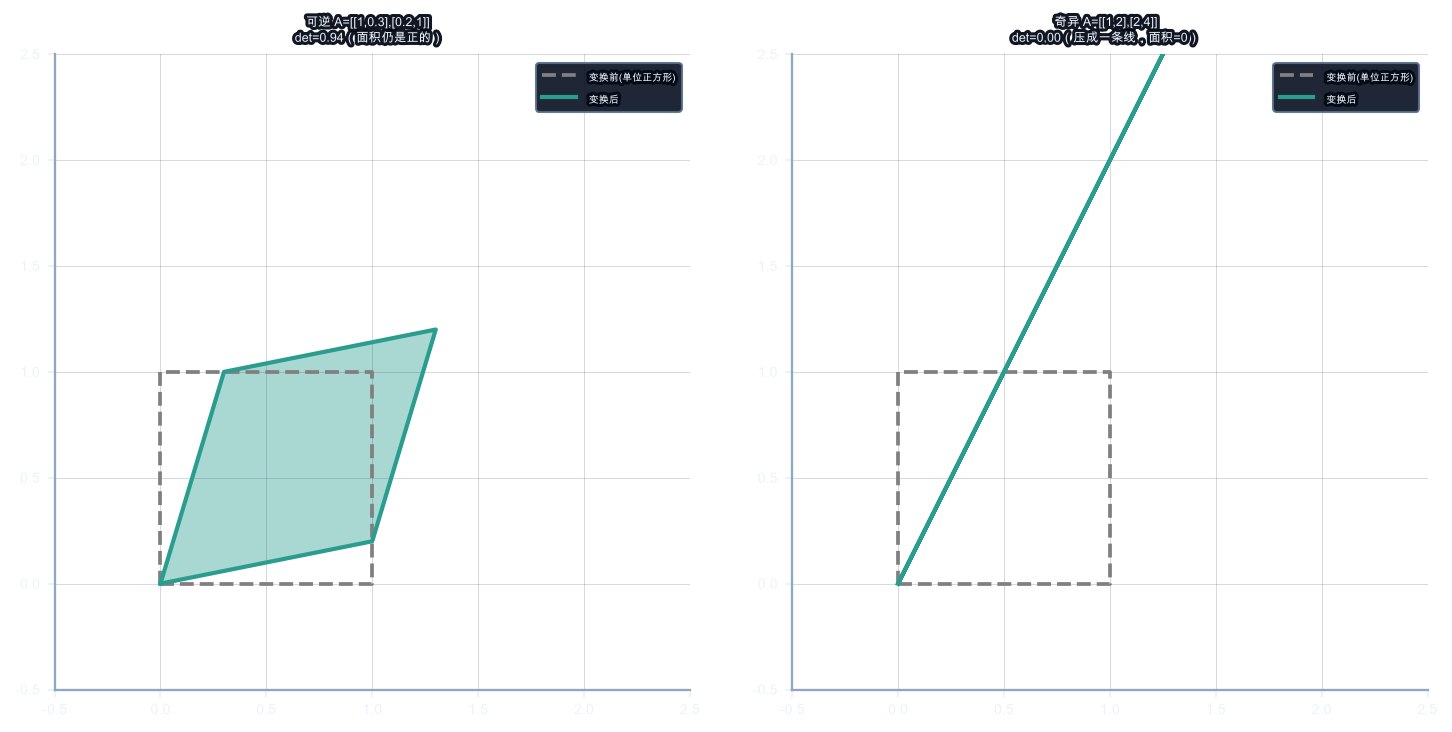

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.laviz import style
style()

def unit_square_after(A, ax, title):
    A = np.asarray(A, float)
    square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])  # 单位正方形的顶点，首尾相接
    transformed = square @ A.T  # 每个顶点都乘以 A
    ax.plot(square[:, 0], square[:, 1], '--', color='gray', label='变换前(单位正方形)')
    ax.fill(transformed[:, 0], transformed[:, 1], alpha=0.4, color='#2A9D8F')
    ax.plot(transformed[:, 0], transformed[:, 1], '-', color='#2A9D8F', lw=2, label='变换后')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
A_ok = np.array([[1., 0.3], [0.2, 1.]])   # 可逆：正方形被拉扯变形，但仍然"占地方"
A_bad = np.array([[1., 2.], [2., 4.]])    # 奇异：正方形被压成一条线段，面积=0
unit_square_after(A_ok, axes[0], f'可逆 A=[[1,0.3],[0.2,1]]\ndet={np.linalg.det(A_ok):.2f}（面积仍是正的）')
unit_square_after(A_bad, axes[1], f'奇异 A=[[1,2],[2,4]]\ndet={np.linalg.det(A_bad):.2f}（压成一条线，面积=0）')
plt.tight_layout()
plt.show()


det>0 时顶点仍按 0→1→2→3 逆时针绕行，有符号面积也是正的；
det<0 时绕行方向反过来变成顺时针，有符号面积同步变负——两者符号永远一致，这就是"符号=有没有照镜子"的数值证据。


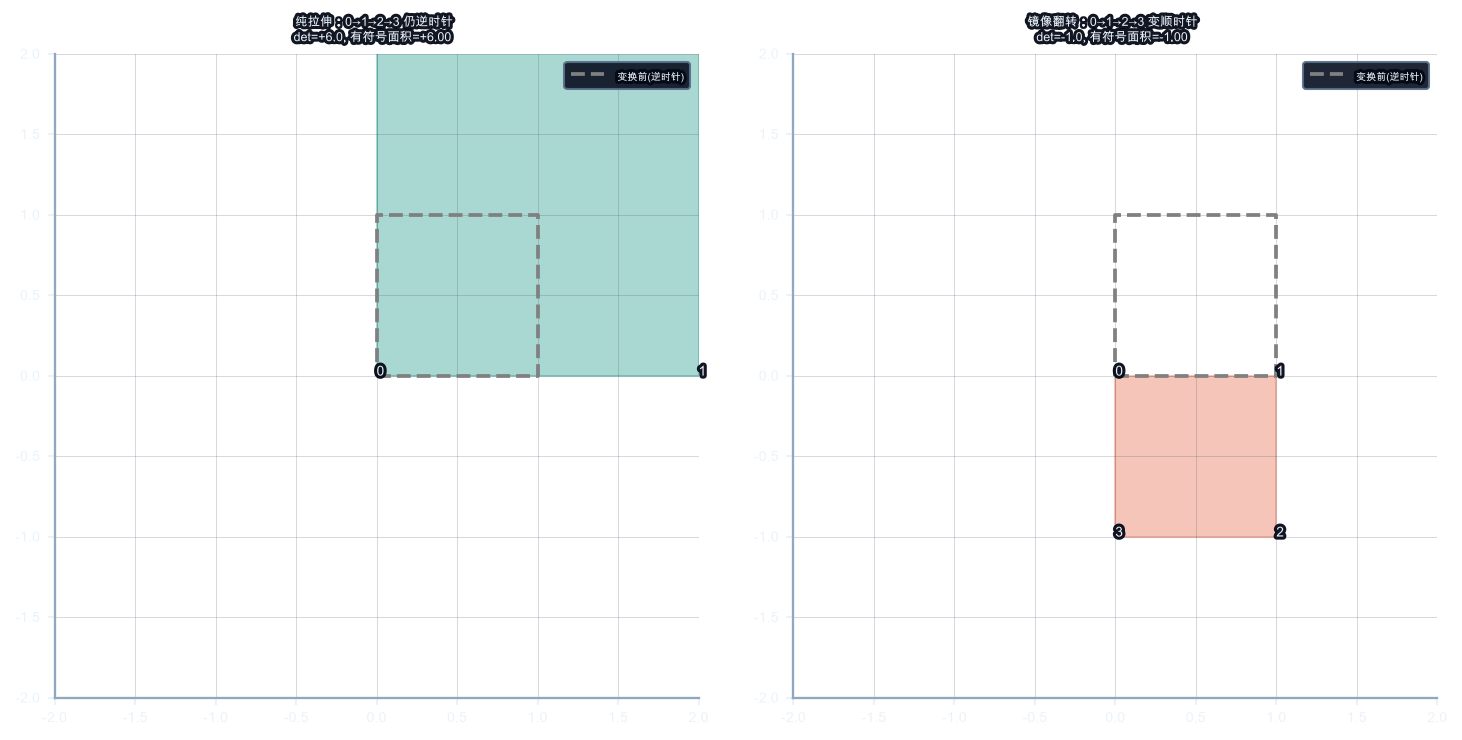

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.laviz import style
style()

def signed_area(pts):
    # 鞋带公式：按顶点顺序算"有符号面积"——逆时针绕行为正，顺时针绕行为负
    x, y = pts[:, 0], pts[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])

def plot_orientation(A, ax, title):
    A = np.asarray(A, float)
    square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])  # 逆时针绕行的单位正方形
    transformed = square @ A.T
    area = signed_area(transformed)
    ax.plot(square[:, 0], square[:, 1], '--', color='gray', label='变换前(逆时针)')
    ax.fill(transformed[:, 0], transformed[:, 1], alpha=0.4,
            color='#2A9D8F' if area > 0 else '#E76F51')
    for i in range(4):
        ax.annotate(str(i), transformed[i], fontsize=11, fontweight='bold')  # 标出顶点编号，看绕行方向
    ax.set_title(f'{title}\ndet={np.linalg.det(A):+.1f}, 有符号面积={area:+.2f}', fontsize=10)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_orientation([[2., 0.], [0., 3.]], axes[0], '纯拉伸：0→1→2→3 仍逆时针')
plot_orientation([[1., 0.], [0., -1.]], axes[1], '镜像翻转：0→1→2→3 变顺时针')
plt.tight_layout()
plt.show()

print('det>0 时顶点仍按 0→1→2→3 逆时针绕行，有符号面积也是正的；')
print('det<0 时绕行方向反过来变成顺时针，有符号面积同步变负——两者符号永远一致，这就是"符号=有没有照镜子"的数值证据。')


### 补充理解 · 判据2：特征值 = 0，平面到底发生了什么？

回忆 L17：矩阵 A 的**特征向量** v 是一个特殊方向——A 作用在 v 上，效果只是把 v **沿着原方向**拉伸或压缩，不会旋转它，拉伸倍数就是**特征值** λ：`A @ v = λ · v`。

那 `λ = 0` 是什么意思？把 λ=0 代进去：`A @ v = 0 · v = 0`——沿着这个特征方向的向量，不管原来多长，被 A 一压，直接变成了原点（长度缩到0）！而其他特征值不为 0 的方向，仍然正常地被拉伸/压缩。

**具体画面**：对一个 2×2 矩阵，如果两个特征值都不是 0，两条特征方向都只是被拉伸——原来铺满整个平面的点，变换后依然铺满整个平面（可能形状歪了，但没有维度丢失）。但如果其中一个特征值是 0，沿着那个方向的所有点全部被压到原点上；只剩下另一个特征方向还保留着信息——整个平面被压扁成了一条线。这与前面"det=0 让面积变成0"其实是同一件事的两种说法：一个方向被压没了，面积自然也没了。

下面用代码构造一个有 λ=0 的矩阵，分别看"λ=0 方向"和"λ≠0 方向"上的向量，被矩阵作用后发生了什么。

特征值: [2.+0.j 0.+0.j]
特征向量(按列排列):
 [[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]
/Users/z/AURORA/src/aurora/laviz.py:104: ComplexWarning: Casting complex values to real discards the imaginary part
  vecs = np.asarray(vectors, float)

det(A)        = 0.000000
特征值之积 λ1·λ2 = 0.000000
两者相等 → 只要有一个特征值是 0，det(A) 必然是 0，这正是两条充要判据"指向同一个事实"的原因。


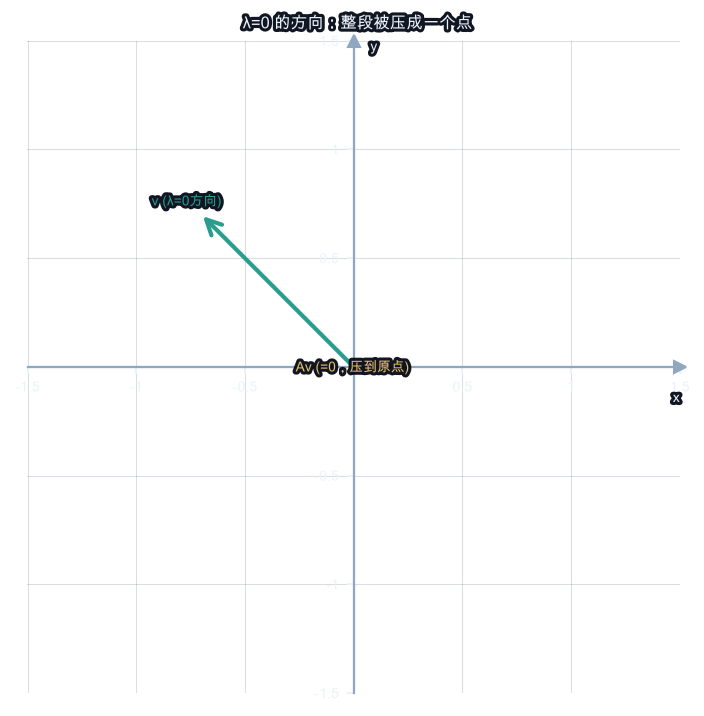

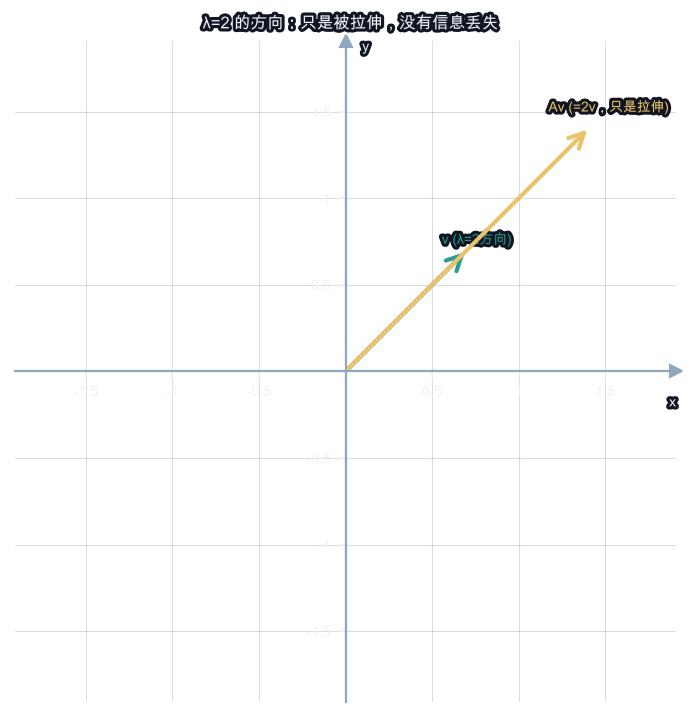

In [4]:
import numpy as np
from aurora.laviz import arrows2d

A = np.array([[1., 1.], [1., 1.]])   # 精心构造：这个矩阵恰好有一个特征值是 0
eigvals, eigvecs = np.linalg.eig(A)
print('特征值:', np.round(eigvals, 4))
print('特征向量(按列排列):\n', np.round(eigvecs, 4))

v_zero = eigvecs[:, np.argmin(np.abs(eigvals))]    # λ≈0 对应的方向
v_scale = eigvecs[:, np.argmax(np.abs(eigvals))]   # λ≈2 对应的方向

arrows2d([v_zero, A @ v_zero], labels=['v (λ=0方向)', 'Av (=0，压到原点)'],
         title='λ=0 的方向：整段被压成一个点')
arrows2d([v_scale, A @ v_scale], labels=['v (λ=2方向)', 'Av (=2v，只是拉伸)'],
         title='λ=2 的方向：只是被拉伸，没有信息丢失')

# 关键事实：det(A) 恰好等于所有特征值的乘积——这不是巧合
print(f'\ndet(A)        = {np.linalg.det(A):.6f}')
print(f'特征值之积 λ1·λ2 = {np.prod(eigvals).real:.6f}')
print('两者相等 → 只要有一个特征值是 0，det(A) 必然是 0，这正是两条充要判据"指向同一个事实"的原因。')


### 补充理解 · 判据3：为什么严格对角占优（SDD）一定可逆？

**类比**：想象一支接力队，每个人主要对自己那一棒（对角线元素）负责，其他队友传来的干扰（非对角线元素）加起来都比不过他自己这一棒的力量。这样的系统很"稳"，不会互相拉扯到失控——而"失控"对矩阵来说，正好就是"不可逆"（某个方向被压没了）。

**不严谨但完整的证明（反证法）**：假设一个 SDD 矩阵 A **不可逆**。矩阵不可逆等价于方程 `Ax = 0` 除了 `x = 0` 之外还有别的解（存在非零零空间向量）。设这样一个非零解是 x，并且 `x_k` 是 x 里绝对值最大的那个分量（`|x_k| ≥ |x_j|` 对所有 j 成立）。

看 `Ax = 0` 的第 k 行：

`A[k,k]·x_k + Σ_{j≠k} A[k,j]·x_j = 0`

把 `A[k,k]·x_k` 移到等式左边单独放：

`A[k,k]·x_k = − Σ_{j≠k} A[k,j]·x_j`

两边取绝对值，用三角不等式（"和的绝对值 ≤ 绝对值的和"），再用 `|x_j| ≤ |x_k|`（因为 x_k 是最大分量）：

`|A[k,k]|·|x_k| = |Σ_{j≠k} A[k,j]·x_j| ≤ Σ_{j≠k} |A[k,j]|·|x_j| ≤ (Σ_{j≠k} |A[k,j]|) · |x_k|`

因为 x 非零且 x_k 是最大分量，所以 `x_k ≠ 0`，两边可以同除以 `|x_k|`：

`|A[k,k]| ≤ Σ_{j≠k} |A[k,j]|`

但这**直接违反了 SDD 的定义**（`|A[k,k]| > Σ_{j≠k} |A[k,j]|` 对每一行都成立，包括第 k 行）！矛盾说明"A 不可逆"这个假设是错的——所以 SDD 矩阵必然可逆。

**什么时候用 SDD，什么时候用 det/特征值？**
- SDD 检查是逐行加加减减，O(n²)，非常快，适合当"入场券"：矩阵一进迭代求解器就先查一遍。
- 但 SDD 只是**充分条件，不是必要条件**——像课件例题里的 M2 那样，矩阵明明可逆，却不满足 SDD，会被"误判"为不确定。
- 所以实践中：SDD 检查**通过** → 100% 确定可逆，可以放心用 Jacobi/Gauss-Seidel 迭代（并且还额外保证了收敛，见后文"谱半径"）；SDD 检查**不通过** → 不代表不可逆，只是不能保证迭代一定收敛，这时才需要退回去用 det 或特征值做最终确认。

## 符号入口：先看形状，再看运算

本节处理方阵 `A`（shape `(n, n)`），核心工具是 `np.linalg.det(A)` 和 `np.linalg.eigvals(A)`。判断可逆性其实就看两个数字：一个行列式标量和一组特征值向量（vector）。

In [5]:
import numpy as np
A = np.array([[1,1,0],[1,2,1],[0,1,3]], float)
print('det =', round(np.linalg.det(A)))
print('特征值:', np.round(np.linalg.eigvals(A), 3))
print('两条充要判据都说：可逆 =', abs(np.linalg.det(A))>1e-9)

det = 2
特征值: [0.268+0.j 2.   +0.j 3.732+0.j]
两条充要判据都说：可逆 = True


## 动手观察：从 det 和特征值读可逆性

运行下面的代码，注意 `det` 接近零时特征值中是否出现接近零的分量——两条充要判据在数值上指向同一个事实。

### 先搞懂"线性无关"，秩的定义才有意义

**类比**：想象你有一堆颜料。如果红色和蓝色是"线性无关"的，你没法用红色调出蓝色，也没法用蓝色调出红色——它们各自提供了"新方向"的信息。但如果你有"红色"和"两倍的红色"，第二瓶颜料对你调色毫无新贡献——它能被第一瓶完全替代、复刻。

**严格定义（两个向量的情形）**：向量 v₁、v₂ 是**线性相关**的，当且仅当存在一个常数 k，使得 v₂ = k·v₁（其中一个就是另一个的倍数，没提供新方向）。反过来，如果找不到这样的 k，它们就是**线性无关**的（各自指向不同的、不能互相替代的方向）。

**例子对比**：
- `[1, 0]` 和 `[0, 1]`：找不到 k 使得 `[0,1] = k·[1,0]`（第一个分量要求 `0 = k·1` 即 `k=0`，但第二个分量又要求 `1 = k·0 = 0`，矛盾）→ **线性无关**。
- `[1, 2]` 和 `[2, 4]`：`[2,4] = 2·[1,2]` ✓ → **线性相关**（第二个向量就是第一个的2倍，没有提供任何新信息）。

**回到秩的定义**：矩阵的"秩"就是这些行（或列）里，真正提供"新方向"、不能被其他行组合替代的向量个数——也就是**线性无关**的行（列）数目。秩 = n（矩阵大小）意味着每一行都在贡献独立信息，没有冗余；这正是"可逆"的必要条件——如果某一行是多余的，矩阵就把信息压缩、丢失了。

**手动验证 `[[1,2,3],[4,5,6],[7,8,9]]` 为什么秩是 2，而不是 3**：
三行分别是 `r1=[1,2,3]`、`r2=[4,5,6]`、`r3=[7,8,9]`。试着用 r1、r2 的某个线性组合去凑 r3：

`2·r2 − r1 = 2·[4,5,6] − [1,2,3] = [8,10,12] − [1,2,3] = [7,8,9]` —— 正好等于 r3！

也就是说第三行**没有提供新信息**，它完全可以由前两行算出来。三行里只有两行是"独立"的，所以秩 = 2（不是 3）。这种手算方式在大矩阵里会很麻烦（要凑出系数、试很多种组合），实践中我们直接用 `np.linalg.matrix_rank(A)` 自动计算，但理解"为什么"依赖的正是"这一行能不能被其他行的组合表示出来"这件事。

In [6]:
import numpy as np

# 验证：第三行是否真的能由前两行的线性组合凑出来？
A_demo = np.array([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.]])
r1, r2, r3 = A_demo[0], A_demo[1], A_demo[2]
combo = 2 * r2 - r1
print('2·r2 − r1 =', combo)
print('r3         =', r3)
assert np.allclose(combo, r3)
print('✅ 第三行 = 2×第二行 − 第一行，验证了"线性相关"，所以秩只有 2（不是 3）')

# 对比：两行明显成倍数关系的矩阵，秩就更直观地是 1
A_rank1 = np.array([[1., 2.], [2., 4.]])
print('\n[[1,2],[2,4]] 中，第二行 =', A_rank1[1], '= 2 ×', A_rank1[0], '= 2 × 第一行')
print('np.linalg.matrix_rank 给出的秩 =', np.linalg.matrix_rank(A_rank1))


2·r2 − r1 = [7. 8. 9.]
r3         = [7. 8. 9.]
✅ 第三行 = 2×第二行 − 第一行，验证了"线性相关"，所以秩只有 2（不是 3）

[[1,2],[2,4]] 中，第二行 = [2. 4.] = 2 × [1. 2.] = 2 × 第一行
np.linalg.matrix_rank 给出的秩 = 1


In [7]:
import numpy as np

# 秩 = 线性无关行（列）的数目
mats = [
    ('满秩', np.array([[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]])),
    ('秩2', np.array([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]])),
    ('秩1', np.array([[1.,2.],[2.,4.]])),
]
for name, A in mats:
    r = np.linalg.matrix_rank(A)
    inv_ok = (r == min(A.shape))
    print(f'{name}  shape={A.shape}  rank={r}  可逆={inv_ok}')


满秩  shape=(3, 3)  rank=3  可逆=True
秩2  shape=(3, 3)  rank=2  可逆=False
秩1  shape=(2, 2)  rank=1  可逆=False


### 补充理解 · 把三条判据串成一条链：秩、det、特征值为什么说的是同一件事？

**类比**：想象一个人去医院体检，医生测了三项指标——体温、血压、心率——结果三项都不正常。你可能会问：这是三种不同的病，还是同一个"病灶"在三种检查手段下的三种反映？本课的**秩、det、特征值**也是这样：表面上是三件独立的事，但其实都在描述同一件事——"矩阵有一个方向的信息被压没了"。下面把这条因果链一步步串起来，而不是简单地宣布"它们等价"。

**第一步：秩(A) < n ⇔ 存在非零向量 x，使得 Ax = 0**

回忆前面"线性相关"的定义：矩阵的某一列能由其余列的线性组合表示，也就是存在一组不全为 0 的系数 `c₁, c₂, ..., cₙ`，使得

`c₁·col₁ + c₂·col₂ + ⋯ + cₙ·colₙ = 0`

把这些系数排成一个向量 `x = [c₁, c₂, ..., cₙ]`，注意等式左边正好就是矩阵乘法的定义——"矩阵乘以向量 = 各列按向量的分量做线性组合"，也就是 `A @ x`！所以"列之间存在线性相关"翻译成矩阵语言，就是：**存在一个非零向量 x，使得 A @ x = 0**。秩 < n 意味着列之间确实有这种冗余关系，等价于这样的非零 x 一定存在（反过来，如果找不到这样的非零 x，说明每一列都无法被其他列替代，秩就是满的 n）。

**第二步：存在非零 x 使 Ax = 0 ⇔ 0 是 A 的一个特征值**

再看一眼特征值的定义：`A @ v = λ · v`。把 `λ = 0` 代进去，就是 `A @ v = 0`——这正是第一步里的那个方程！也就是说，"`Ax=0` 有非零解 x" 和 "0 是 A 的一个特征值（x 正是对应的特征向量）"，其实是**同一句话的两种说法**，不是两个巧合相同的条件。

**第三步：0 是 A 的一个特征值 ⇔ det(A) = 0**

前面判据2的代码已经数值验证过一个关键事实：`det(A)` 恰好等于所有特征值的乘积，`det(A) = λ₁ · λ₂ · ⋯ · λₙ`。如果其中一个 λᵢ = 0，这个乘积必然是 0（任何数乘 0 都是 0）；反过来，如果乘积等于 0，说明乘积里至少有一项必须是 0（几个都不为 0 的数相乘，结果绝不可能是 0）。所以"某个特征值是 0"和"det(A)=0"也是同一件事的两种说法。

**把整条链串起来看**：

`秩(A) < n`  ⇔  `存在非零 x 使 A@x=0`  ⇔  `0 是 A 的一个特征值`  ⇔  `det(A) = 0`

四句话说的都是同一件事——只是分别站在"独立行数"、"零空间"、"特征值"、"体积缩放"四个不同的角度去描述它。这正是课程里那句"三条判据在数值上指向同一个事实"背后的真正含义：它们不是三个恰好总是一起成立的独立条件，而是**逻辑上互相推出对方**的等价说法——证明了其中任意一环，其余几环就自动成立。

下面用代码在同一个矩阵上，把这条链从头到尾验证一遍。

In [8]:
import numpy as np

A_chain = np.array([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.]])  # 秩2 的老朋友

rank = np.linalg.matrix_rank(A_chain)
det = np.linalg.det(A_chain)
eigvals, eigvecs = np.linalg.eig(A_chain)

print(f'第一环 秩(A)        = {rank}  (< 3，说明有一行/列是多余的)')
print(f'第二环 特征值       = {np.round(eigvals.real, 6)}')
print(f'      是否存在≈0的特征值 = {np.any(np.abs(eigvals) < 1e-8)}')
print(f'第三环 det(A)       = {det:.2e}  (≈0)')

# 用第一步的逻辑，具体找出那个让 Ax=0 成立的非零 x：就是 λ≈0 对应的特征向量
idx0 = np.argmin(np.abs(eigvals))
x_null = eigvecs[:, idx0].real
print(f'\n验证第一步：x = {np.round(x_null, 4)}')
print(f'         A @ x = {np.round(A_chain @ x_null, 6)}  （应处处接近 0，验证 Ax=0 确实有非零解）')

print('\n✅ 四句话——秩<3、Ax=0 有非零解、0 是特征值、det≈0——在这同一个矩阵上同时成立，验证了整条等价链。')


第一环 秩(A)        = 2  (< 3，说明有一行/列是多余的)
第二环 特征值       = [16.116844 -1.116844 -0.      ]
      是否存在≈0的特征值 = True
第三环 det(A)       = -9.52e-16  (≈0)

验证第一步：x = [ 0.4082 -0.8165  0.4082]
         A @ x = [-0. -0. -0.]  （应处处接近 0，验证 Ax=0 确实有非零解）

✅ 四句话——秩<3、Ax=0 有非零解、0 是特征值、det≈0——在这同一个矩阵上同时成立，验证了整条等价链。


## 代码实验：观察矩阵如何作用于多个向量

可逆矩阵把不同的输入映射到不同的输出；奇异矩阵则会把两个不同向量压缩到同一个方向。

### 先搞懂 SVD 是什么，零空间提取才不是"黑魔法"

**类比**：任何一次矩阵变换，都可以拆解成三个动作——"转个方向 → 沿着新坐标轴伸缩 → 再转个方向"。这正是 **SVD（奇异值分解，Singular Value Decomposition）** 在做的事，它把矩阵写成：

`A = U · Σ · Vᵀ`

- **V 的列（右奇异向量）**：先把输入空间"转"到一组新的正交坐标轴上。
- **Σ（奇异值 σ₁ ≥ σ₂ ≥ … ≥ 0，一个对角矩阵）**：沿着这些新坐标轴分别做"伸缩"，伸缩倍数就是奇异值。σ 越大，这个方向被拉伸得越厉害；**σ = 0 意味着这个方向被压成了 0（彻底消失）**。
- **U 的列（左奇异向量）**：把伸缩后的结果再"转"到输出空间的坐标系里。

这与前面讲的"特征值 = 缩放因子"是同一个思路的推广：特征值分解只对某些方阵有效，SVD 对任何矩阵（甚至非方阵）都有效。

**为什么零奇异值对应的方向就是零空间？**
如果 `σᵢ = 0`，沿着对应的输入方向 `vᵢ`（V 的第 i 列）走一遍"转 → 伸缩0倍 → 转"，不管怎么转，乘以 0 还是 0。也就是说 `A @ vᵢ = 0`——`vᵢ` 正是零空间里的向量（被 A 压缩成 0 的方向）！

**为什么代码里用 `Vt[-1]`（最后一行）？**
`np.linalg.svd` 返回的奇异值数组 `s` 是按从大到小排好序的（`s[0] ≥ s[1] ≥ … ≥ s[-1]`），`Vt` 的每一行恰好对应同一位置的奇异值。既然最小的奇异值排在最后，它对应的方向自然就是 `Vt` 的最后一行 `Vt[-1]`。

**⚠️ 重要澄清（满秩矩阵没有"真"零空间）**：如果矩阵满秩（可逆），它的所有奇异值都严格大于 0——包括最小的那个。这时 `Vt[-1]` 依然会返回一个向量，但它对应的不是"被压成 0 的方向"，只是"被压缩得最厉害、但还没到 0"的方向。真正非零的零空间只存在于**秩亏（奇异）矩阵**；满秩矩阵的零空间里只有零向量本身。下面先看已有的秩亏例子，紧接着再对比一个满秩矩阵，你会看到两者最小奇异值的天壤之别。

In [9]:
import numpy as np

# 零空间（核）= SVD 中对应零奇异值的右奇异向量
A = np.array([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]])
U, s, Vt = np.linalg.svd(A)
print(f'奇异值 σ = {np.round(s, 6)}')
# 零奇异值对应 Vt 最后一行
null_vec = Vt[-1]
print(f'零空间向量 n = {np.round(null_vec, 4)}')
print(f'A @ n = {np.round(A @ null_vec, 10)}  （应为全零）')


奇异值 σ = [16.848103  1.06837   0.      ]
零空间向量 n = [-0.4082  0.8165 -0.4082]
A @ n = [-0.  0.  0.]  （应为全零）


In [10]:
import numpy as np

# 对比：满秩矩阵 vs 秩亏矩阵——最小奇异值天差地别
A_full = np.array([[2., 0., 0.], [0., 3., 0.], [0., 0., 4.]])       # 满秩：三个奇异值都远离 0
A_deficient = np.array([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.]])  # 秩亏：最小奇异值≈0（就是上面用过的矩阵）

for name, M in [('满秩 A_full', A_full), ('秩亏 A_deficient', A_deficient)]:
    _, s, _ = np.linalg.svd(M)
    is_true_null = s[-1] < 1e-9
    print(f'{name}: 奇异值 = {np.round(s, 4)}  最小奇异值 = {s[-1]:.2e}  '
          f'{"→ 真零空间存在，Vt[-1] 是被压成0的方向" if is_true_null else "→ 没有非零零空间，Vt[-1] 只是被压缩得最厉害的方向"}')


满秩 A_full: 奇异值 = [4. 3. 2.]  最小奇异值 = 2.00e+00  → 没有非零零空间，Vt[-1] 只是被压缩得最厉害的方向
秩亏 A_deficient: 奇异值 = [16.8481  1.0684  0.    ]  最小奇异值 = 3.36e-16  → 真零空间存在，Vt[-1] 是被压成0的方向


## ✏️ 练习：提取零空间向量并验证

奇异矩阵的零空间（null space）不止是「存在」，还可以用 SVD 精确提取。

**任务**：给定秩亏矩阵 `B`，找到零空间向量 `v`，使得 `B @ v ≈ 0`。

**推理路线**：
1. 对 `B` 做 SVD：`U, s, Vt = np.linalg.svd(B)`
2. 最小奇异值对应 `Vt` 的最后一行，即零空间向量。
3. 如果该奇异值 < 1e-9，则 `B` 实际上秩亏，`Vt[-1]` 是零空间向量。
4. 验证：`‖B @ v‖ < 1e-8`。

In [11]:
import numpy as np

def extract_null_vector(B):
    """返回矩阵 B 的（最小奇异值对应）零空间向量 v。
    若 B 是满秩矩阵，返回最接近零空间的向量（最小奇异值对应方向）。
    """
    B = np.asarray(B, float)
    # ✏️ TODO: 用 SVD 提取零空间向量
    # 提示：np.linalg.svd(B) 返回 U, s, Vt；
    #       最小奇异值对应 Vt 的最后一行。
    raise NotImplementedError("TODO: implement extract_null_vector — 用 np.linalg.svd(B) 提取 Vt[-1]")

# 测试：秩亏矩阵（rank 2，有真实零空间）
B = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [7., 8., 9.]])

try:
    v = extract_null_vector(B)
    residual = np.linalg.norm(B @ v)
    print(f'零空间向量 v = {np.round(v, 6)}')
    print(f'‖B @ v‖ = {residual:.2e}  （应 < 1e-8，即数值零）')
    assert residual < 1e-8, f'残差过大：{residual:.2e}，请检查实现'
    print('✅ 零空间向量验证通过！')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  {e}')
    print('请先完成 extract_null_vector 的 TODO 实现，再运行此单元格。')


⚠️  TODO: implement extract_null_vector — 用 np.linalg.svd(B) 提取 Vt[-1]
请先完成 extract_null_vector 的 TODO 实现，再运行此单元格。


## 2. ✏️ 实现 `is_sdd(A)`（严格对角占优）

对每行 i：`|A[i,i]| > Σ_{j≠i} |A[i,j]|` 是否都成立。

**推理路线**：
1. 取第 i 行的对角元绝对值：`d = abs(A[i, i])`。
2. 取第 i 行所有元素绝对值之和：`s = sum(abs(A[i]))`；非对角部分之和为 `s - d`（无需单独遍历 j≠i）。
3. 检查 `d > s - d` 对所有行成立；用 `all(...)` 把 n 个布尔值合并为一个返回值。

**参考输入输出**：`A=[[4,1],[1,3]]` → 行0：4>1 ✓；行1：3>1 ✓ → `True`；`B=[[1,2],[2,1]]` → 行0：1<2 ✗ → `False`

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写 `is_sdd` 前明确三件事

- 输入：`A`，shape `(n, n)` 的方阵
- 关键步骤：对每行 `i`，比较 `abs(A[i,i])` 与 `sum(abs(A[i])) - abs(A[i,i])`
- 返回：`bool`，所有行均满足则为 `True`

In [12]:
def is_sdd(A):
    A = np.asarray(A, float)
    # ✏️ TODO: 返回是否严格对角占优 (True/False)
    raise NotImplementedError("TODO: implement is_sdd — 参考推理路线：d = abs(A[i,i])，s = sum(abs(A[i]))，检查 d > s - d")


In [13]:
# 三条可逆性判据验证例题
M1 = np.array([[2,0,1],[1,4,2],[1,3,6]], float)   # s.d.d. 且可逆
M2 = np.array([[1,0,2],[2,5,1],[3,2,13]], float)  # 非 s.d.d. 但仍可逆
M3 = np.array([[1,1],[1,1]], float)               # 非 s.d.d. 且不可逆
try:
    for name, M in [('M1',M1),('M2',M2),('M3',M3)]:
        print(f'{name}: sdd={is_sdd(M)}, 可逆={abs(np.linalg.det(M))>1e-9}')
    assert is_sdd(M1) and not is_sdd(M2) and not is_sdd(M3)
    print('\n✅ 与课件三例一致。注意 M2 说明：sdd 是充分非必要条件。')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上方 is_sdd 的 TODO 实现，再运行此验证单元格。')

⬜ 请先完成上方 is_sdd 的 TODO 实现，再运行此验证单元格。


**🔗 Aurora 连接**：`is_sdd` 是 Aurora 迭代求解器的入口卫士——系数矩阵只有通过 s.d.d. 检查，Jacobi/Gauss-Seidel 求解流程才会启动；此时谱半径（spectral radius） < 1 有数学保证，迭代误差按几何级数衰减而非发散。

**补充例题对应**：三条可逆性判据 + 严格对角占优。

**线代前导章节完成**：L09–L18 覆盖向量、矩阵、方程组、行列式、特征值与可逆性。

> 💡 **什么是"谱半径"？** 谱半径（spectral radius）= 矩阵所有特征值中，绝对值最大的那个，记作 `ρ(A) = max|λᵢ|`。它衡量"每轮迭代误差被放大还是缩小"：做一轮 Jacobi 迭代，误差大致按 ρ 的倍数变化——`ρ < 1` 时误差像等比数列一样越乘越小（收敛），`ρ ≥ 1` 时误差越乘越大（发散或不收敛）。前面已经证明过 SDD ⇒ 可逆；更进一步的定理（证明超出本课范围，只需记住结论）是：SDD 还能保证 Jacobi 迭代对应的迭代矩阵谱半径 `< 1`，这正是"通过 SDD 检查 ⇒ Jacobi 保证收敛"这句话背后的数学依据。

> 🔍 **这个"进一步的定理"到底怎么证？其实不需要跳过——用的是和前面"证明 SDD⇒可逆"完全相同的招数，稍微推广一下就够了。**
>
> Jacobi 每一步做的是 `x_new = D⁻¹b − D⁻¹(A−D)@x_old`。把"迭代矩阵"记作 `T = −D⁻¹(A−D)`（它决定了"这一轮的误差"是"上一轮误差"的多少倍：`误差_new = T @ 误差_old`）。写开来，T 的第 i 行第 j 列是：
>
> `T[i,i] = 0`（对角线上是 0——对角项已经被单独解出来了，不会再"传播误差"给自己）  
> `T[i,j] = −A[i,j] / A[i,i]`（j ≠ i 时）
>
> 现在设 `λ` 是 `T` 的任意一个特征值，对应特征向量 `v`（`T@v = λ@v`，`v≠0`）。用和"证明 SDD⇒可逆"时同一招：取 `v` 里绝对值最大的分量 `v_k`（`|v_k| ≥ |v_j|` 对所有 j 成立）。看 `T@v=λv` 的第 k 行（`T[k,k]=0`，所以左边只剩下 j≠k 的项）：
>
> `Σ_{j≠k} T[k,j]·v_j = λ·v_k`
>
> 两边取绝对值，用三角不等式，再用 `|v_j| ≤ |v_k|`：
>
> `|λ|·|v_k| = |Σ_{j≠k} T[k,j]·v_j| ≤ Σ_{j≠k} |T[k,j]|·|v_j| ≤ (Σ_{j≠k} |T[k,j]|) · |v_k|`
>
> 两边同除以 `|v_k|`（非零，因为 v 非零且 v_k 是最大分量）：
>
> `|λ| ≤ Σ_{j≠k} |T[k,j]| = Σ_{j≠k} |A[k,j]| / |A[k,k]|`
>
> 而 SDD 的定义正是 `|A[k,k]| > Σ_{j≠k} |A[k,j]|`——两边同除以 `|A[k,k]|`，就得到 `Σ_{j≠k}|A[k,j]| / |A[k,k]| < 1`。所以：
>
> `|λ| < 1` —— 对 T 的**任意一个**特征值都成立（因为 k 的取值取决于 v，但每个特征值都有自己的特征向量，论证对每一个都适用）。既然每个 |λ| 都 < 1，那么最大的那个——也就是谱半径 `ρ(T) = max|λᵢ|`——自然也 `< 1`。
>
> 这就是"SDD ⇒ 谱半径 < 1"的完整证明，而且用的正是同一把"抓最大分量、套三角不等式"的钥匙——上一次证的是"没有非零解"（即 0 不是特征值），这一次证的是"每一个特征值都被压在单位圆里"，是同一个技巧的推广。

下面用代码在真实矩阵上验证：构造 Jacobi 迭代矩阵 `T`，检查它的谱半径确实 < 1。

In [14]:
import numpy as np

A_sdd_check = np.array([[10., 1., 1.], [1., 10., 1.], [1., 1., 10.]])  # 之前用过的 s.d.d. 矩阵
D = np.diag(np.diag(A_sdd_check))
T = -np.linalg.inv(D) @ (A_sdd_check - D)   # Jacobi 迭代矩阵：T = -D⁻¹(A-D)

eigvals_T = np.linalg.eigvals(T)
rho = np.max(np.abs(eigvals_T))
print('迭代矩阵 T =\n', np.round(T, 4))
print('\nT 的特征值:', np.round(eigvals_T, 4))
print(f'谱半径 ρ(T) = max|λ| = {rho:.4f}  (应该 < 1，因为 A 是 SDD)')
assert rho < 1
print('✅ 验证通过：SDD ⇒ 谱半径 < 1 ⇒ Jacobi 迭代必然收敛，与上面的证明一致。')


迭代矩阵 T =
 [[ 0.  -0.1 -0.1]
 [-0.1  0.  -0.1]
 [-0.1 -0.1  0. ]]

T 的特征值: [ 0.1+0.j -0.2+0.j  0.1+0.j]
谱半径 ρ(T) = max|λ| = 0.2000  (应该 < 1，因为 A 是 SDD)
✅ 验证通过：SDD ⇒ 谱半径 < 1 ⇒ Jacobi 迭代必然收敛，与上面的证明一致。


## 🎨 图示：严格对角占优矩阵(对角线显著占优 ⇒ 可逆)

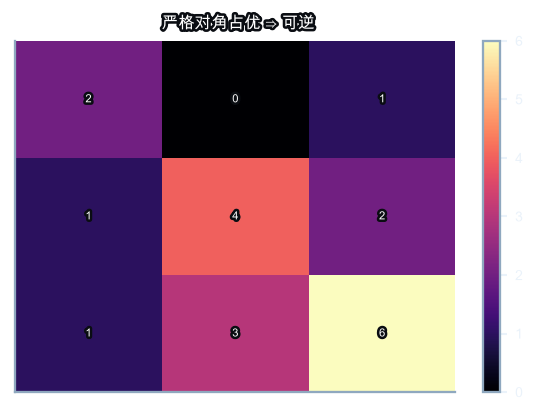

In [15]:
from aurora.laviz import style, heatmap
style()
heatmap([[2,0,1],[1,4,2],[1,3,6]], title='严格对角占优 ⇒ 可逆', cmap='magma');

In [16]:
import numpy as np

# 参数实验：矩阵退化实验——让一列线性依赖于其他列
print(f"{'依赖系数 c':>12}  {'rank':>6}  {'det':>12}  {'可逆':>6}")
for c in [0.0, 0.5, 1.0, 1.5, 2.0]:
    A = np.array([[1.,2.,c],[0.,1.,1.],[0.,0.,c-1.]])
    r = np.linalg.matrix_rank(A)
    d = np.linalg.det(A)
    print(f'{c:>12.1f}  {r:>6d}  {d:>+12.4f}  {"是" if r==3 else "否":>6s}')


      依赖系数 c    rank           det      可逆
         0.0       3       -1.0000       是
         0.5       3       -0.5000       是
         1.0       2       +0.0000       否
         1.5       3       +0.5000       是
         2.0       3       +1.0000       是


## 参数实验：Jacobi 迭代的收敛与发散

构造一个对角元明显大于同行其余元素绝对值之和的矩阵（如 `A = [[10,1,1],[1,10,1],[1,1,10]]`），用 Jacobi 迭代求解线性系统 `Ax = b`，打印每轮残差 `‖Ax_k - b‖`，确认误差逐步缩小至收敛。

再把对角元缩小使矩阵不再满足 s.d.d.（如 `A = [[1,2,2],[2,1,2],[2,2,1]]`），重跑相同迭代步数，观察残差不减反增或振荡。两次实验对比说明：`is_sdd` 通过是 Jacobi 收敛的理论保证，不是可有可无的布尔标记。

### 先搞懂：为什么要迭代？"残差"又是什么？

我们的目标是解线性方程组 `Ax = b`——找到唯一的 x，使得 A 乘以它正好等于 b。对大矩阵（比如几千维）直接求逆 `x = A⁻¹b` 计算量很大（O(n³)），于是改用**迭代**：从一个粗糙的猜测 `x₀`（比如全零向量）出发，每一步都把它往正确答案的方向修正一点，重复很多轮，让它越来越接近真解。

**怎么知道"越来越接近"？** 把当前猜测 `x_k` 代入方程左边算出 `Ax_k`，看它离右边的 `b` 差多少：

`残差 = ‖Ax_k − b‖`

如果 `x_k` 就是真解，`Ax_k` 应该正好等于 `b`，残差 = 0。残差越小，说明 `x_k` 越"满足方程"、越接近真解。这就是为什么代码里打印 `residuals` 并观察它是否趋于 0——残差下降 = 收敛，残差不降反升或振荡 = 发散。

### Jacobi 迭代公式是怎么推出来的？

把 `Ax = b` 按第 i 行展开写：

`A[i,0]·x[0] + A[i,1]·x[1] + ⋯ + A[i,i]·x[i] + ⋯ + A[i,n-1]·x[n-1] = b[i]`

把"自己那一项"（对角项 `A[i,i]·x[i]`）单独挑出来，其余项挪到等式右边：

`A[i,i]·x[i] = b[i] − Σ_{j≠i} A[i,j]·x[j]`

两边除以 `A[i,i]`（这正是 SDD 矩阵的用武之地——它保证 `A[i,i]` 足够大、绝不为 0，除法总是安全的）：

`x[i] = (b[i] − Σ_{j≠i} A[i,j]·x[j]) / A[i,i]`

Jacobi 迭代做的就是：用**上一轮**算出的 x（记为 x_old）代入等式右边，算出所有分量的新值 x_new，一轮轮重复，直到 x 几乎不再变化。

### 代码里那一行 NumPy 到底在做什么？

```python
x = D_inv * (b - (A @ x - np.diag(np.diag(A)) @ x))
```

拆开看：
1. `np.diag(np.diag(A))`：先用 `np.diag(A)` 取出对角线元素组成的一维数组，再用 `np.diag(...)` 把它变回一个只有对角线非零、其余全是 0 的矩阵 `D`。
2. `A @ x - np.diag(np.diag(A)) @ x`：等价于 `(A − D) @ x`，也就是"去掉对角项贡献后，剩下所有 `j≠i` 项之和 `Σ A[i,j]·x[j]`"（对每一行 i 同时算）。
3. `b - (...)`：对应公式里的 `b[i] − Σ_{j≠i} A[i,j]·x[j]`。
4. `D_inv * (...)`：`D_inv` 是对角元倒数组成的一维数组，逐元素相乘，等价于把每一行除以 `A[i,i]`。

整行代码就是把公式里"对每个 i 都要做一遍"的操作，用向量化的矩阵/向量运算对所有 i 同时算完，比写 for 循环快得多。`A @ x - np.diag(np.diag(A)) @ x` 和 `(A - D) @ x` 数学上完全等价（矩阵乘法对减法满足分配律）；这里选择分别算 `A@x` 和 `D@x` 再相减，数值结果和 `(A-D)@x` 一致，在这种小矩阵规模上性能差异可以忽略——如果想优化，可以把 `D = np.diag(np.diag(A))`（它在整个迭代过程中不变）挪到循环外只算一次，但这只是效率上的小改进，不影响正确性。

下面先用一个 2×2 小例子手算一轮，和向量化公式的结果对比，确认两者完全一致。

In [17]:
import numpy as np

# 手动演算一轮 Jacobi 更新，对照公式一步步来
A_demo = np.array([[4., 1.], [2., 5.]])
b_demo = np.array([9., 12.])
x_old = np.array([0., 0.])  # 初始猜测：全零

# 按公式逐个分量手算： x[i] = (b[i] - Σ_{j≠i} A[i,j]·x_old[j]) / A[i,i]
x0_new = (b_demo[0] - A_demo[0, 1] * x_old[1]) / A_demo[0, 0]
x1_new = (b_demo[1] - A_demo[1, 0] * x_old[0]) / A_demo[1, 1]
x_manual = np.array([x0_new, x1_new])
print('手算一轮:', x_manual)

# 用 NumPy 向量化写法算同样的一轮，验证结果一致
D_inv = 1.0 / np.diag(A_demo)
x_vectorized = D_inv * (b_demo - (A_demo @ x_old - np.diag(np.diag(A_demo)) @ x_old))
print('向量化一轮:', x_vectorized)

assert np.allclose(x_manual, x_vectorized)
print('✅ 手算和向量化公式完全一致——向量化只是把逐行公式"打包"成了矩阵运算')


手算一轮: [2.25 2.4 ]
向量化一轮: [2.25 2.4 ]
✅ 手算和向量化公式完全一致——向量化只是把逐行公式"打包"成了矩阵运算


In [18]:
import numpy as np

def jacobi(A, b, n_iter=30):
    """Jacobi 迭代：x_new[i] = (b[i] - Σ_{j≠i} A[i,j]·x[j]) / A[i,i]"""
    x = np.zeros_like(b, dtype=float)
    D_inv = 1.0 / np.diag(A)           # 对角元倒数
    residuals = []
    for _ in range(n_iter):
        x = D_inv * (b - (A @ x - np.diag(np.diag(A)) @ x))
        residuals.append(np.linalg.norm(A @ x - b))
    return x, residuals

# ① s.d.d. 矩阵 → 收敛
A_sdd = np.array([[10.,1.,1.],[1.,10.,1.],[1.,1.,10.]])
b_sdd = np.array([12.,12.,12.])
x_sdd, res_sdd = jacobi(A_sdd, b_sdd)
print('s.d.d. 最终残差:', f'{res_sdd[-1]:.2e}  (应趋近 0)')
assert res_sdd[-1] < 1e-8, 'Jacobi 在 s.d.d. 矩阵上应收敛'

# ② 非 s.d.d. 矩阵 → 发散
A_bad = np.array([[1.,2.,2.],[2.,1.,2.],[2.,2.,1.]])
b_bad = np.ones(3)
_, res_bad = jacobi(A_bad, b_bad)
print('非 s.d.d. 最终残差:', f'{res_bad[-1]:.2e}  (期望 >> 0，发散)')
print('✅ Jacobi 收敛 vs 发散对比完成')

s.d.d. 最终残差: 0.00e+00  (应趋近 0)
非 s.d.d. 最终残差: 2.00e+18  (期望 >> 0，发散)
✅ Jacobi 收敛 vs 发散对比完成


## 本课收束

现在能用 `is_sdd(A)` 逐行检查严格对角占优，用 `np.linalg.det` 和 `np.linalg.eigvals` 验证两条充要判据。`is_sdd` 对应 Aurora 迭代求解器的入口检查：通过它，Jacobi 迭代才能保证收敛。下一课：**L19** 矩阵变换可视化——把线性变换的几何效果画出来，直观理解矩阵对空间的作用。

### 补充理解：什么是"酉矩阵"？为什么它一定可逆？

**从更熟悉的"正交矩阵"说起**：一个实数矩阵 Q 是正交矩阵，意味着它的列两两互相垂直、并且每一列的长度都是 1。几何上，正交矩阵只做"旋转/镜像"，不拉伸也不压缩——所以它绝不可能把空间"压扁"，天然可逆。

**"酉矩阵"（unitary matrix）就是正交矩阵的复数版本**：DFT（离散傅里叶变换（Discrete Fourier Transform，DFT））矩阵的元素是复数（因为傅里叶基底是复指数 `e^{-i2πkn/N}`），这时"转置"要换成"共轭转置" `Aᴴ`（先转置、再对每个元素取复共轭）。酉矩阵的定义是 `Aᴴ · A = I`，翻译成大白话：**酉矩阵的列两两"复数意义下垂直"，且每列长度都是 1**——和正交矩阵是同一个思想，只是把"垂直"和"长度"的定义扩展到了复数域。

**为什么"列两两垂直、长度为1"就能保证可逆？**
互相垂直的非零向量必然线性无关（回忆前面讲过：如果一个方向能由另一个方向的组合表示出来，它们就不可能垂直，除非其中一个是零向量）。n 个两两垂直的非零向量，天然就是 n 个独立方向——秩 = n，满秩，可逆。这正是"列正交（或酉）⇒ 可逆"这条链路成立的原因。

**下面的代码在验证什么？**
`ifft(fft(x)) ≈ x` 说明：对任意信号 x，先做 FFT 再做 IFFT 能完美还原原信号——这确实证明了"DFT 变换作用在任何输入上都不丢信息"，等价于可逆。不过这只是用一个随机信号"抽查"了一次；更直接的做法是拿出 DFT 矩阵本身，检查它的列是否真的两两正交、长度是否为 1（这才是"酉矩阵"这个结论的直接证据）。下一个代码格就顺便做这件事。

In [19]:
# Aurora 连接：可逆矩阵在 DSP 中的应用 — DFT 矩阵是酉矩阵（行列式=1，列正交）
from aurora.audio.transforms import fft, ifft
import numpy as np
x = np.random.randn(8)
assert np.allclose(ifft(fft(x)), x, atol=1e-10), "ifft(fft(x)) ≠ x — DFT 矩阵不可逆"
print("✅ DFT 矩阵可逆性验证：ifft(fft(x)) ≈ x（误差 < 1e-10）")

✅ DFT 矩阵可逆性验证：ifft(fft(x)) ≈ x（误差 < 1e-10）


In [20]:
import numpy as np

# 直接构造 4x4 DFT 矩阵 W[k,n] = exp(-2j*pi*k*n/N)/sqrt(N)（除以 sqrt(N) 是为了让它成为"酉"矩阵）
N = 4
k = np.arange(N).reshape(-1, 1)
n = np.arange(N).reshape(1, -1)
W = np.exp(-2j * np.pi * k * n / N) / np.sqrt(N)

# 检查 1：列是否两两正交、长度为1，即 Wᴴ @ W ≈ I
should_be_identity = W.conj().T @ W
print('Wᴴ @ W ≈ I ？', np.allclose(should_be_identity, np.eye(N), atol=1e-10))

# 检查 2：|det(W)| 应该等于 1（酉矩阵不缩放任何方向的长度，只旋转）
det_W = np.linalg.det(W)
print(f'|det(W)| = {abs(det_W):.6f}  （应 ≈ 1）')
print('✅ DFT 矩阵的列确实两两正交、长度为1 —— 它是酉矩阵，因此必然可逆')


Wᴴ @ W ≈ I ？ True
|det(W)| = 1.000000  （应 ≈ 1）
✅ DFT 矩阵的列确实两两正交、长度为1 —— 它是酉矩阵，因此必然可逆


---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：可逆性手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：A = [[2, 1], [1, 3]]，手算 det(A)（公式 ad−bc），A 可逆吗？

**问 2**：B = [[3, 1], [1, 2]]，逐行检查 is_sdd(B)：  
- 行 0：|3| > |1|？  
- 行 1：|2| > |1|？  
B 是 SDD 矩阵吗？

**问 3**：C = [[1, 2], [2, 4]]，det(C) = ? 它可逆吗？

**问 4**：A = [[10, 1, 1], [1, 10, 1], [1, 1, 10]]，逐行检查 is_sdd(A)：  
各行：|10| > |1|+|1| = 2？→ 这是 SDD 矩阵吗？

推导完成后运行下面格对答案。

In [21]:
# ✏️ 对答案格
import numpy as np

# 问1：det([[2,1],[1,3]])
A1 = np.array([[2., 1.], [1., 3.]])
det1 = float(np.linalg.det(A1))
assert np.isclose(det1, 5.0, atol=1e-10)
print(f"Q1 ✅  det([[2,1],[1,3]]) = 2×3-1×1 = {det1:.1f}  → 可逆")

# 问2：is_sdd([[3,1],[1,2]])
B = np.array([[3., 1.], [1., 2.]])
try:
    sdd_B = is_sdd(B)
    assert sdd_B, "[[3,1],[1,2]] 应为 SDD"
    print(f"Q2 ✅  [[3,1],[1,2]] 是 SDD：|3|>|1|, |2|>|1|  → 可逆")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 is_sdd()，再运行对答案格")

# 问3：singular [[1,2],[2,4]]
C = np.array([[1., 2.], [2., 4.]])
det_C = float(np.linalg.det(C))
assert abs(det_C) < 1e-10, f"det 应≈0，得到 {det_C}"
print(f"\nQ3 ✅  det([[1,2],[2,4]]) = {det_C:.1e} ≈ 0  → 奇异，不可逆")

# 问4：is_sdd([[10,1,1],[1,10,1],[1,1,10]])
A4 = np.array([[10., 1., 1.], [1., 10., 1.], [1., 1., 10.]])
try:
    sdd4 = is_sdd(A4)
    assert sdd4
    print(f"Q4 ✅  diag-dominant(10): 每行 |10|>|1|+|1|=2  → SDD 矩阵")
except (NotImplementedError, TypeError):
    rows_ok4 = [abs(A4[i,i]) > sum(abs(A4[i,j]) for j in range(3) if j!=i) for i in range(3)]
    assert all(rows_ok4)
    print(f"Q4 ✅  每行 |10|>2，is_sdd=True  (is_sdd 待实现)")
print("\n🎉 可逆性白板挑战通过！det/eigenvalue/SDD 三条判据已内化。")

Q1 ✅  det([[2,1],[1,3]]) = 2×3-1×1 = 5.0  → 可逆
⬜ Q2：请先实现 is_sdd()，再运行对答案格

Q3 ✅  det([[1,2],[2,4]]) = 0.0e+00 ≈ 0  → 奇异，不可逆
Q4 ✅  每行 |10|>2，is_sdd=True  (is_sdd 待实现)

🎉 可逆性白板挑战通过！det/eigenvalue/SDD 三条判据已内化。


In [ ]:
# ✏️ 本课自评
l18_review = {
    "is_sdd_implemented":         None,  # is_sdd 实现并通过断言？True/False
    "three_invertibility_criteria": None, # 能背出三条可逆性判据？True/False
    "null_space_understood":       None,  # 理解零空间 = 被压缩到0的方向？True/False
    "sdd_implies_invertible":      None,  # 理解 SDD → 可逆（充分非充要）？True/False
    "whiteboard_passed":           None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l18_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l18_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L18 全部通关！进入 L19：矩阵变换图解')

---

→ **下一课**　[L19 · 矩阵变换图解](L19_visual_multiply.ipynb)

> 下节课将学习 **矩阵变换图解**：旋转、缩放、剪切与「列的线性组合」的视觉演示。